# The DGR endorsement uplift, step by step: where 30% and 47% come from

This notebook reproduces the uplift estimates used in the reform impact modelling, from the switcher panel outward. Every number is computed in front of you.

**Source data:** `switcher_panel.csv`, produced by `dgr_endorsement_event_study.R` — ACNC Annual Information Statements 2019–2024 joined to ABR DGR endorsement dates. One row per charity per financial year, for charities that *gained* DGR endorsement during the window ("switchers"), excluding ancillary funds.

**The two headline numbers, one sentence each:**
- **+47%** — median within-charity donation growth after endorsement, in *nominal* dollars (as reported).
- **+30%** — the same calculation in *real* (CPI-adjusted, FY2019) dollars. **Our central estimate.**

A robustness section at the end shows the estimate barely moves when we guard against "anticipation" (charities ramping up fundraising while their DGR application is in flight).

> **Provenance note (2026-07-29):** earlier drafts quoted a low case of +24%, described as an anticipation haircut. When we tried to reproduce it from the data for this notebook, we couldn't — the anticipation-robust estimate is ~29%, not 24%. The 24% figure has been dropped from the pipeline (`reform_scenario_impact.R`). The honest range is **30% (real, central) to 47% (nominal)**, with the anticipation check supporting the central figure.

In [1]:
from pathlib import Path

import pandas as pd

HERE = Path("analysis/dgr_event_study") if Path("analysis").exists() else Path(".")
panel = pd.read_csv(HERE / "switcher_panel.csv")

print(f"Rows: {len(panel):,} | Charities: {panel['abn'].nunique():,}")
panel.head()

Rows: 3,770 | Charities: 691


,abn,charity_legal_name,charity_size,ais_year,endorsement_fy,event_year,is_startup,donations_and_bequests,total_gross_income,donation_share
0,11260987026,HIGHFIELDS PIONEER VILLAGE MUSEUM AND PARK INC,Small,2019,2020,-1,True,15758.0,236956.0,0.066502
1,11363125088,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,Small,2019,2021,-2,False,7412.0,69426.0,0.106761
2,12451824370,Chairo Parent Governed Christian Education Lim...,Large,2019,2021,-2,False,12135.0,31395711.0,0.000387
3,12454623050,Sydney Eye Hospital Foundation Trust,Medium,2019,2023,-4,False,860929.0,1675098.0,0.513957
4,12608879741,A Chance For Change Ltd,Small,2019,2020,-1,False,71815.0,92696.0,0.774737


## Step 1 — Keep only *established* switchers

A charity endorsed within a year of registering has no meaningful "before" — its donation growth is just start-up ramp-up, not a DGR effect. We exclude those (`is_startup`) and keep charities that existed and reported *before* getting DGR.

In [2]:
est = panel[~panel["is_startup"]].copy()
print(f"Established switcher charities: {est['abn'].nunique():,} "
      f"({est['abn'].nunique() / panel['abn'].nunique():.0%} of all switchers)")
est.groupby("endorsement_fy")["abn"].nunique().rename("charities endorsed").to_frame()

Established switcher charities: 646 (93% of all switchers)


,charities endorsed
endorsement_fy,
2020,161
2021,183
2022,160
2023,142


## Step 2 — Event time: line every charity up on its endorsement year

`event_year` counts financial years relative to each charity's endorsement:

| event_year | meaning |
|---|---|
| −2, −1 | before endorsement ("pre") |
| 0 | the year endorsement landed — *partly treated, so excluded from both sides* |
| +1, +2, … | after endorsement ("post") |

Here is one real charity so you can see the structure:

In [3]:
example_abn = (
    est.groupby("abn")
    .filter(lambda g: (g["event_year"] < 0).sum() >= 2 and (g["event_year"] >= 1).sum() >= 2)
    ["abn"].iloc[0]
)
est.loc[est["abn"] == example_abn,
        ["charity_legal_name", "ais_year", "event_year", "donations_and_bequests", "total_gross_income"]
].sort_values("ais_year")

,charity_legal_name,ais_year,event_year,donations_and_bequests,total_gross_income
1,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2019,-2,7412.0,69426.0
522,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2020,-1,40198.0,114935.0
1111,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2021,0,112694.0,175364.0
1757,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2022,1,145384.0,215466.0
2432,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2023,2,173008.0,227273.0
3104,EDUCATION WITHOUT BORDERS (AUSTRALIA) INCORPOR...,2024,3,104824.0,153299.0


## Step 3 — The 47%: nominal within-charity growth

For **each charity**:
1. **pre** = average donations across its years before endorsement (`event_year < 0`)
2. **post** = average donations across its clean years after (`event_year >= 1`)
3. **growth** = (post − pre) ÷ pre — with pre floored at \\$1 so zero-donation baselines don't divide by zero

Then take the **median across charities**. Using the median means one whale can't drag the answer around — this is the growth of the *typical* newly endorsed charity.

In [4]:
def within_charity_growth(df, value_col, pre_years=None):
    """Per-charity (post mean - pre mean) / pre mean.
    pre = event_year < 0 (or a custom condition), post = event_year >= 1."""
    if pre_years is None:
        pre_mask = df["event_year"] < 0
    else:
        pre_mask = df["event_year"].isin(pre_years)
    g = pd.DataFrame({
        "pre": df[pre_mask].groupby("abn")[value_col].mean(),
        "post": df[df["event_year"] >= 1].groupby("abn")[value_col].mean(),
    }).dropna()
    g["growth"] = (g["post"] - g["pre"]) / g["pre"].clip(lower=1)
    return g

nom = within_charity_growth(est, "donations_and_bequests")

print(f"Charities with both pre and post years: {len(nom):,}")
print(f"Median pre-period donations:  ${nom['pre'].median():>10,.0f}")
print(f"Median post-period donations: ${nom['post'].median():>10,.0f}")
print(f"Share of charities whose donations rose: {(nom['post'] > nom['pre']).mean():.0%}")
print(f"\nMEDIAN NOMINAL GROWTH: {nom['growth'].median():+.1%}   <-- the 47%")

Charities with both pre and post years: 646
Median pre-period donations:  $     8,738
Median post-period donations: $    17,601
Share of charities whose donations rose: 61%

MEDIAN NOMINAL GROWTH: +47.0%   <-- the 47%


## Step 4 — The 30%: strip out inflation

2019–2024 spans the fastest inflation in decades. A charity whose donations "grew" ~15% in cash terms merely kept pace with prices. We deflate every year's dollars to FY2019 purchasing power using the ABS CPI (6401.0, financial-year average, 2019 = 100), then rerun the **identical** calculation.

In [5]:
CPI = {2019: 100.0, 2020: 101.4, 2021: 103.1, 2022: 107.2, 2023: 114.7, 2024: 119.4}

est["donations_real"] = est["donations_and_bequests"] * 100 / est["ais_year"].map(CPI)

real = within_charity_growth(est, "donations_real")
print(f"MEDIAN REAL GROWTH: {real['growth'].median():+.1%}   <-- the 30% (central estimate)")
print(f"\nThe {nom['growth'].median() - real['growth'].median():+.0%}-point gap vs nominal is inflation:")
print(f"a typical pre year (~2020, CPI 101.4) vs post year (~2023, CPI 114.7)")
print(f"is a {114.7 / 101.4 - 1:.0%} price-level rise that does nothing for charities.")

MEDIAN REAL GROWTH: +29.6%   <-- the 30% (central estimate)

The +17%-point gap vs nominal is inflation:
a typical pre year (~2020, CPI 101.4) vs post year (~2023, CPI 114.7)
is a 13% price-level rise that does nothing for charities.


## Interlude — four pictures of the same effect

Before the robustness checks, the evidence visually, from individual to aggregate:

1. **Every charity's before → after as a slope** — the growth itself, one line per charity.
2. **Staggered cohorts, each indexed to its own pre-endorsement level** — the rise starts at each cohort's own endorsement year (the pseudo-counterfactual).
3. **Growth by size band** — the uplift is broad-based, not an artefact of tiny or huge charities.
4. **The full growth distribution** — why the median (+30%) is the conservative summary.

### Picture 1 — before → after, one line per charity

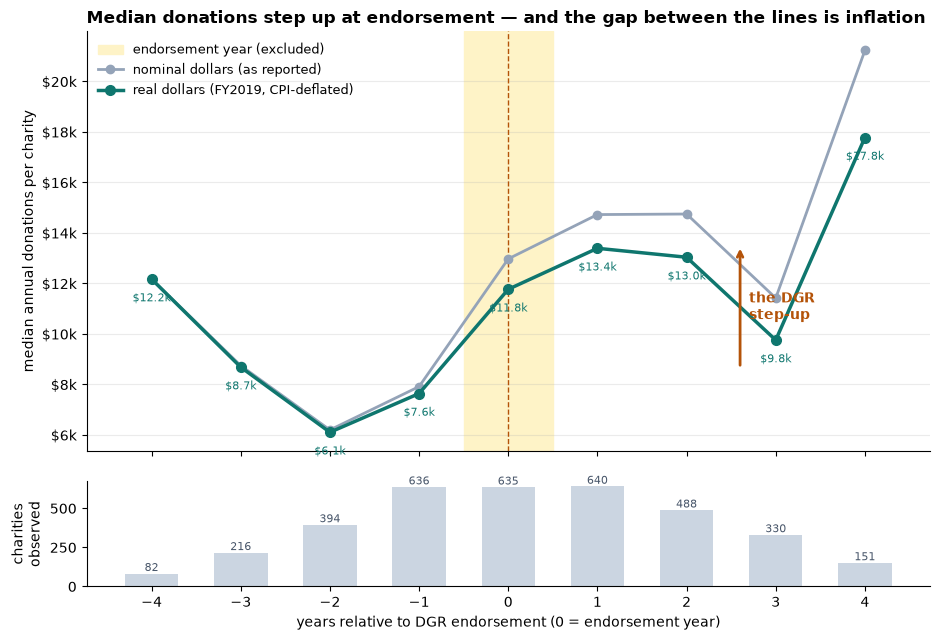

Caution at the edges: event years -4 and +4 are observed for only one cohort each
(endorsed FY2023 and FY2020 respectively), so their medians mix cohort composition with time.


In [ ]:
# Picture 1 — every charity's before -> after, drawn as a slope
import matplotlib.pyplot as plt
import numpy as np

d = real.copy()  # per-charity pre/post means, real dollars (from Step 4)
FLOOR = 100
up = d["post"] > d["pre"]

fig, ax = plt.subplots(figsize=(8.5, 6.5))

for pre_v, post_v, rose in zip(d["pre"].clip(lower=FLOOR), d["post"].clip(lower=FLOOR), up):
    ax.plot([0, 1], [pre_v, post_v], color="#0f766e" if rose else "#b91c1c",
            alpha=0.10, lw=0.8, zorder=1)

# bold median charity line
med_pre, med_post = d["pre"].median(), d["post"].median()
ax.plot([0, 1], [med_pre, med_post], "o-", color="black", lw=3, ms=9, zorder=3)
ax.annotate(f"median charity\n${med_pre:,.0f} -> ${med_post:,.0f}",
            xy=(0.5, (med_pre * med_post) ** 0.5), xytext=(0.52, med_pre * 6),
            fontsize=10.5, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2), zorder=4)

ax.set_yscale("log")
ax.set_xticks([0, 1])
ax.set_xticklabels(["BEFORE endorsement\n(mean of pre years)", "AFTER endorsement\n(mean of post years)"], fontsize=10)
ax.set_xlim(-0.12, 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}" if v < 1e6 else f"${v/1e6:g}m"))
ax.set_ylabel("annual donations (real FY2019 $, log scale)")
ax.set_title(f"One line per charity (n={len(d):,}): {up.mean():.0%} tilt up, {(~up).mean():.0%} tilt down\n"
             f"median real growth +{d['growth'].median():.0%}",
             fontsize=12, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color="#0f766e", lw=2, label=f"donations rose ({up.sum()} charities)"),
    Line2D([0], [0], color="#b91c1c", lw=2, label=f"donations fell ({(~up).sum()} charities)"),
    Line2D([0], [0], color="black", lw=3, label="median charity"),
], loc="lower right", frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

### Picture 2 — the pseudo-counterfactual: four cohorts, four different lift-off years

The strongest causal evidence we have. Each panel is one endorsement cohort, indexed to **its own pre-endorsement median = 100** (indexing removes level differences between cohorts so the timing is the only thing left to see). If donation growth were COVID generosity, inflation, or an economy-wide trend, all four panels would rise in the **same calendar year**. Instead the lift-off tracks each cohort's own endorsement band.

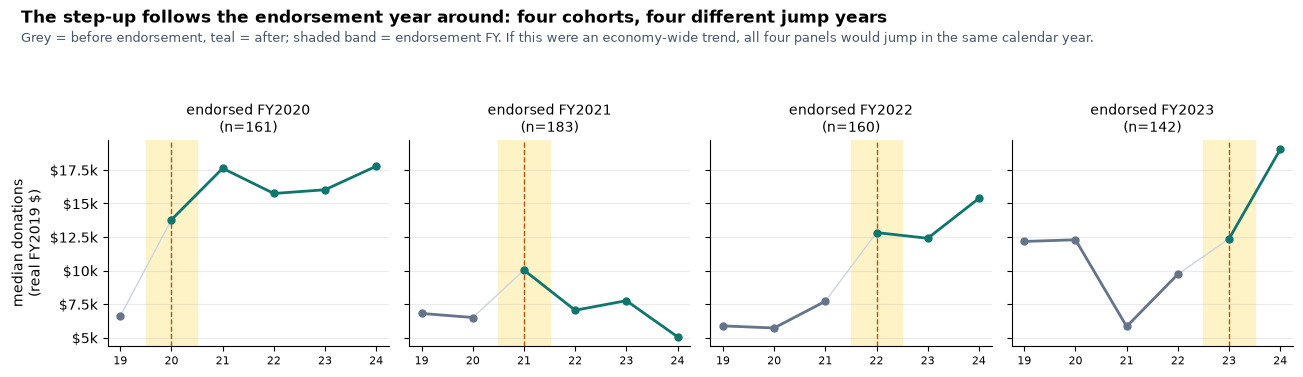

In [ ]:
# Picture 2 — staggered cohorts, indexed to each cohort's own pre-endorsement median = 100
import matplotlib.pyplot as plt

cohorts = sorted(est["endorsement_fy"].unique())
fig, axes = plt.subplots(1, len(cohorts), figsize=(13, 3.9), sharey=True)

for ax, fy in zip(axes, cohorts):
    sub = est[est["endorsement_fy"] == fy]
    med = sub.groupby("ais_year")["donations_real"].median()
    base = med[med.index < fy].mean()          # cohort's own pre-endorsement level
    med_idx = 100 * med / base
    n_ch = sub["abn"].nunique()

    pre_years = [y for y in med_idx.index if y < fy]
    post_years = [y for y in med_idx.index if y >= fy]
    ax.axhline(100, color="#94a3b8", lw=1, ls=":", zorder=1)
    ax.axvspan(fy - 0.5, fy + 0.5, color="#fef3c7", zorder=0)
    ax.axvline(fy, color="#b45309", lw=1, ls="--", zorder=1)
    ax.plot(med_idx.index, med_idx.values, color="#cbd5e1", lw=1, zorder=2)
    ax.plot(pre_years, med_idx.loc[pre_years], "o-", color="#64748b", lw=2, ms=5, zorder=3)
    ax.plot(post_years, med_idx.loc[post_years], "o-", color="#0f766e", lw=2, ms=5, zorder=3)

    post_avg = med_idx.loc[[y for y in post_years if y > fy]].mean()
    ax.annotate(f"post avg\n{post_avg:.0f}", xy=(max(med_idx.index), post_avg),
                xytext=(4, 0), textcoords="offset points",
                fontsize=8.5, color="#0f766e", fontweight="bold", va="center")

    ax.set_title(f"endorsed FY{fy}\n(n={n_ch})", fontsize=10)
    ax.set_xticks(med_idx.index)
    ax.set_xticklabels([str(y)[2:] for y in med_idx.index], fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("median real donations\n(cohort pre-endorsement = 100)")
fig.suptitle("Each cohort vs its own pre-endorsement level (=100): the rise starts at each cohort's own endorsement year",
             fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.text(0.01, 0.885, "Grey = before, teal = after, shaded band = endorsement FY. Dotted line = cohort's pre-endorsement level. "
         "An economy-wide trend would lift all four panels in the same calendar year — instead the lift-off tracks the treatment.",
         fontsize=9, color="#475569")
fig.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

### Picture 3 — is the growth broad-based, or a size artefact?

Percentage growth on a tiny base is cheap; a sceptic will ask whether the +30% is all sub-$1k charities doubling from nothing. Splitting by pre-endorsement donation level answers it: the median charity grew in **every** size band — including those already raising over $100k a year — and the right panel shows the actual dollars behind each percentage.

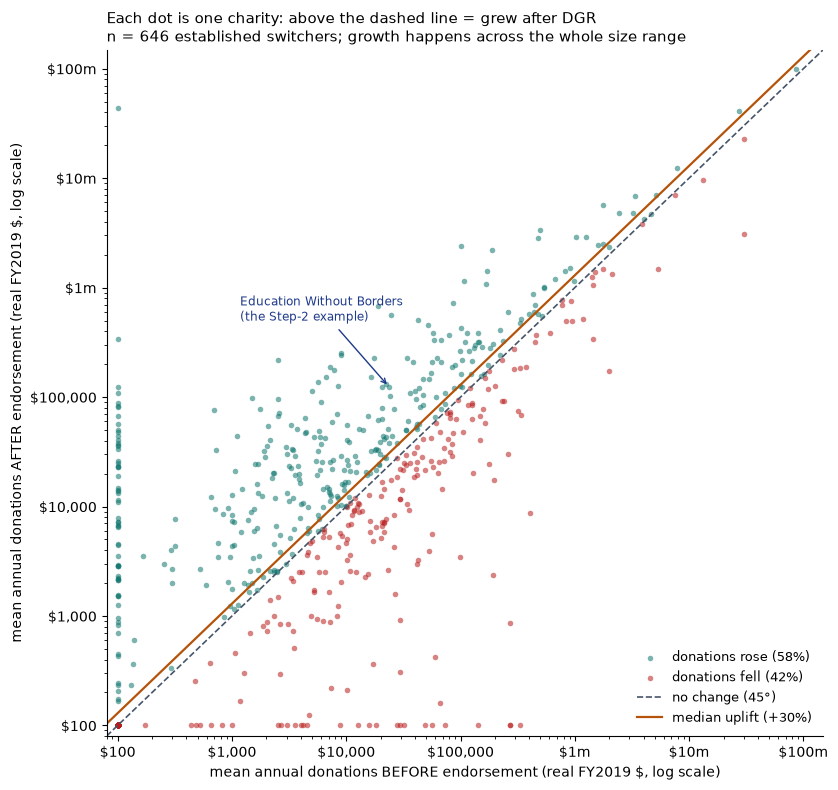

In [ ]:
# Picture 3 — is the growth broad-based? Median growth by charity size band
import matplotlib.pyplot as plt
import numpy as np

d = real.copy()
bands = [0, 1_000, 10_000, 100_000, np.inf]
labels = ["< $1k\n(incl. zero base)", "$1k – $10k", "$10k – $100k", "> $100k"]
d["band"] = pd.cut(d["pre"], bands, labels=labels, right=False)

by_band = d.groupby("band", observed=True).agg(
    n=("growth", "size"),
    med_growth=("growth", "median"),
    share_up=("growth", lambda s: (s > 0).mean()),
    med_pre=("pre", "median"),
    med_post=("post", "median"),
)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))

# Left: median growth per size band
colors = ["#14b8a6", "#0f766e", "#0e5e57", "#0b4742"]
xp = np.arange(len(by_band))
capped = by_band["med_growth"].clip(upper=1.0)
bars = ax.bar(xp, capped, color=colors, width=0.6)
for i, (v, n) in enumerate(zip(by_band["med_growth"], by_band["n"])):
    lbl = f"+{v:.0%}" if v < 10 else f"+{v:,.0f}x"
    ax.annotate(f"{lbl}\n(n={n})", (i, min(v, 1.0)), xytext=(0, 6),
                textcoords="offset points", ha="center", fontsize=9.5, fontweight="bold")
ax.axhline(d["growth"].median(), color="#b45309", lw=1.5, ls="--")
ax.annotate(f"all charities: +{d['growth'].median():.0%}", xy=(2.6, d["growth"].median()),
            xytext=(0, 5), textcoords="offset points", color="#b45309", fontsize=9, fontweight="bold")
ax.set_xticks(xp); ax.set_xticklabels(labels, fontsize=9)
ax.set_xlabel("pre-endorsement donation level (real $/yr)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"+{v:.0%}"))
ax.set_ylim(0, 1.15)
ax.set_title("Median real growth is positive in every size band\n(smallest band capped at +100% for display)",
             fontsize=10.5, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

# Right: median pre vs post dollars per band — the dollars behind the percentages
width = 0.38
ax2.bar(xp - width / 2, by_band["med_pre"], width, color="#94a3b8", label="before (median $)")
ax2.bar(xp + width / 2, by_band["med_post"], width, color="#0f766e", label="after (median $)")
for i, (a_v, b_v) in enumerate(zip(by_band["med_pre"], by_band["med_post"])):
    ax2.annotate(f"${a_v/1000:,.0f}k" if a_v >= 1000 else f"${a_v:,.0f}",
                 (i - width / 2, a_v), xytext=(0, 3), textcoords="offset points",
                 ha="center", fontsize=8, color="#475569")
    ax2.annotate(f"${b_v/1000:,.0f}k" if b_v >= 1000 else f"${b_v:,.0f}",
                 (i + width / 2, b_v), xytext=(0, 3), textcoords="offset points",
                 ha="center", fontsize=8, color="#0f766e", fontweight="bold")
ax2.set_yscale("log")
ax2.set_xticks(xp); ax2.set_xticklabels(labels, fontsize=9)
ax2.set_xlabel("pre-endorsement donation level (real $/yr)")
ax2.set_ylabel("median annual donations (log scale)")
ax2.set_title("Median dollars before vs after, by size band", fontsize=10.5, loc="left")
ax2.legend(frameon=False, fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle("The uplift is broad-based: not a small-charity artefact, not driven by a few big winners",
             fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

by_band.assign(med_growth=lambda t: (100 * t["med_growth"]).round(0),
               share_up=lambda t: (100 * t["share_up"]).round(0))

### Picture 4 — the whole distribution, not just the median

The +30% is one number summarising 646 very different stories. The histogram shows the full spread; the cumulative curve shows why the **median is the conservative choice** — the distribution is heavily right-skewed (some charities grow 10× after endorsement), so a mean would be far larger and indefensible.

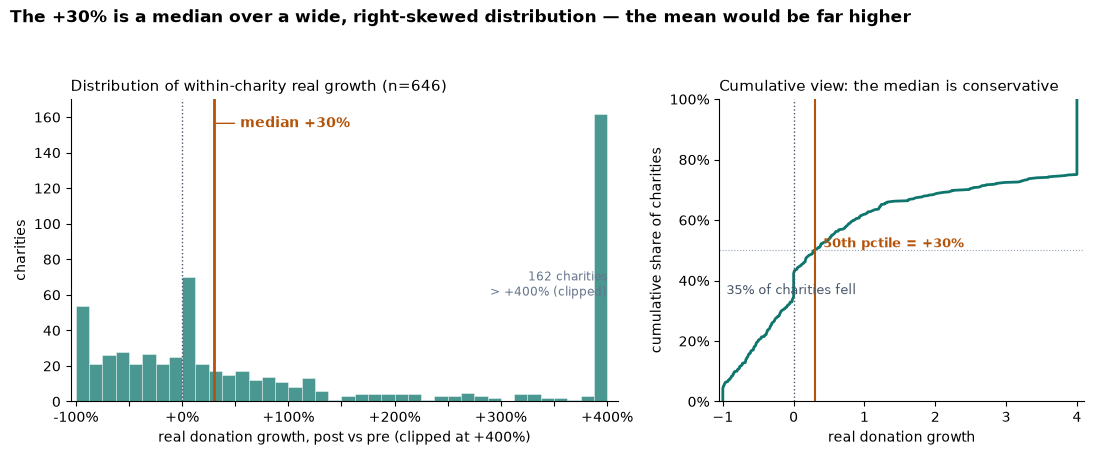

Why the median: growth ratios explode for near-zero baselines. Even restricted to charities with pre >= $1,000 (n=495),
the mean is +249% vs median +21% - the median is the defensible summary.


In [13]:
# Picture 4 — the full distribution of per-charity real growth
import matplotlib.pyplot as plt
import numpy as np

g = real["growth"]
med_real_g = g.median()
med_nom_g = nom["growth"].median()

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [3, 2]})

clipped = g.clip(-1, 4)
ax.hist(clipped, bins=np.arange(-1, 4.1, 0.125), color="#0f766e", alpha=0.75, edgecolor="white", lw=0.4)
ax.axvline(0, color="#475569", lw=1, ls=":")
ax.axvline(med_real_g, color="#b45309", lw=2)
ax.annotate(f"median {med_real_g:+.0%}", xy=(med_real_g, ax.get_ylim()[1] * 0.92),
            xytext=(med_real_g + 0.25, ax.get_ylim()[1] * 0.92),
            color="#b45309", fontsize=10, fontweight="bold", va="center",
            arrowprops=dict(arrowstyle="-", color="#b45309", lw=1))
ax.set_xlim(-1.05, 4.1)
ax.set_xticks(np.arange(-1, 4.5, 0.5))
ax.set_xticklabels([f"{x:+.0%}" if x in (-1, 0, 1, 2, 3, 4) else "" for x in np.arange(-1, 4.5, 0.5)])
ax.set_xlabel("real donation growth, post vs pre (clipped at +400%)")
ax.set_ylabel("charities")
ax.set_title(f"Distribution of within-charity real growth (n={len(g):,})", fontsize=11, loc="left")
n_above4 = (g > 4).sum()
ax.annotate(f"{n_above4} charities\n> +400% (clipped)", xy=(4, ax.get_ylim()[1] * 0.35),
            ha="right", fontsize=8.5, color="#64748b")

# ECDF: where does the typical charity sit?
xs = np.sort(g.values)
ys = np.arange(1, len(xs) + 1) / len(xs)
ax2.plot(np.clip(xs, -1, 4), ys, color="#0f766e", lw=2)
ax2.axhline(0.5, color="#94a3b8", lw=0.8, ls=":")
ax2.axvline(0, color="#475569", lw=1, ls=":")
ax2.axvline(med_real_g, color="#b45309", lw=1.5)
share_neg = (g < 0).mean()
ax2.annotate(f"{share_neg:.0%} of charities fell", xy=(-0.95, share_neg), va="bottom", fontsize=9, color="#475569")
ax2.annotate(f"50th pctile = {med_real_g:+.0%}", xy=(med_real_g + 0.12, 0.51), fontsize=9,
             color="#b45309", fontweight="bold")
ax2.set_xlim(-1.05, 4.1)
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.set_xlabel("real donation growth")
ax2.set_ylabel("cumulative share of charities")
ax2.set_title("Cumulative view: the median is conservative", fontsize=11, loc="left")

for a in (ax, ax2):
    a.spines[["top", "right"]].set_visible(False)
fig.suptitle("The +30% is a median over a wide, right-skewed distribution — the mean would be far higher",
             fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

meaningful = real[real["pre"] >= 1000]
print(f"Why the median: growth ratios explode for near-zero baselines. Even restricted to "
      f"charities with pre >= $1,000 (n={len(meaningful):,}),")
print(f"the mean is {meaningful['growth'].mean():+.0%} vs median {meaningful['growth'].median():+.0%} "
      f"- the median is the defensible summary.")

## Step 5 — Robustness: is it just pre-endorsement momentum?

The worry: charities *apply* for DGR before they *get* it, often with donors or a campaign already lined up. If donations start rising during the application year, the final pre year (−1) is contaminated and the simple pre/post split flatters the DGR effect.

Two checks:
1. **Drift test** — among charities observed at both −2 and −1, did donations already rise between those two years?
2. **Clean-baseline rerun** — recompute the real growth using only `event_year <= -2` as the baseline, so any ramp-up in year −1 can't inflate the result.

In [6]:
# Check 1: within-charity drift from -2 to -1 (real dollars, balanced sample)
w = (est[est["event_year"].isin([-2, -1])]
     .pivot_table(index="abn", columns="event_year", values="donations_real")
     .dropna())
drift = (w[-1] - w[-2]) / w[-2].clip(lower=1)
print(f"Balanced charities at -2 and -1: {len(w):,}")
print(f"Median within-charity drift -2 to -1: {drift.median():+.1%}")
print(f"Share rising -2 to -1: {(w[-1] > w[-2]).mean():.0%}   (i.e. no systematic pre-trend)")

# Check 2: clean baseline (pre = event_year <= -2 only)
clean = within_charity_growth(est, "donations_real", pre_years=[-4, -3, -2])
print(f"\nMedian real growth with clean (<= -2) baseline: {clean['growth'].median():+.1%} "
      f"(n={len(clean):,})")
print(f"vs central estimate:                            {real['growth'].median():+.1%} "
      f"(n={len(real):,})")
print("\n=> The central +30% is not driven by anticipation: guarding against it")
print("   moves the estimate by well under a percentage point.")

Balanced charities at -2 and -1: 386
Median within-charity drift -2 to -1: +0.0%
Share rising -2 to -1: 45%   (i.e. no systematic pre-trend)

Median real growth with clean (<= -2) baseline: +29.3% (n=400)
vs central estimate:                            +29.6% (n=646)

=> The central +30% is not driven by anticipation: guarding against it
   moves the estimate by well under a percentage point.


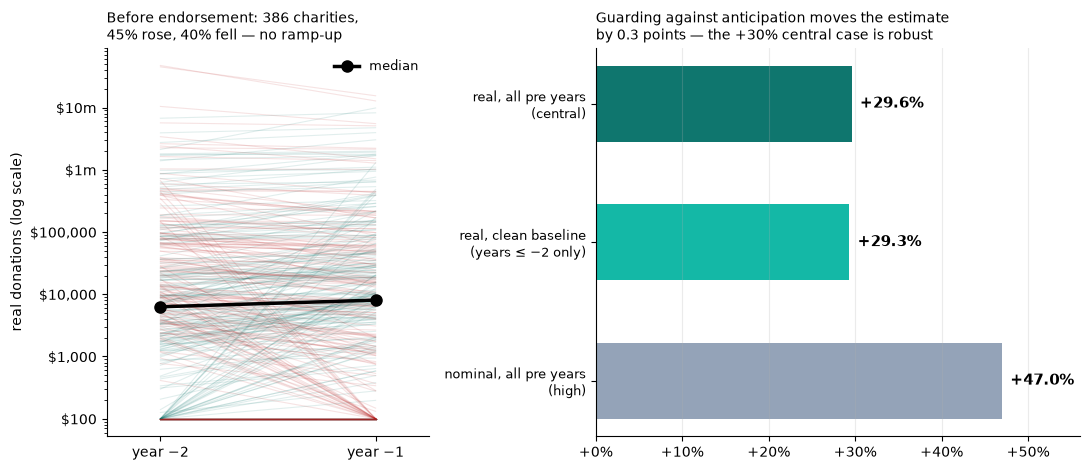

In [14]:
# Picture 5 — anticipation check, visually: paired slopes from -2 to -1
import matplotlib.pyplot as plt
import numpy as np

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.8), gridspec_kw={"width_ratios": [2, 3]})

# Left: every charity's -2 -> -1 move (log scale), coloured by direction
wp = w.clip(lower=100)
up = w[-1] > w[-2]
for i, (a, b) in enumerate(zip(wp[-2], wp[-1])):
    ax.plot([0, 1], [a, b], color="#0f766e" if up.iloc[i] else "#b91c1c",
            alpha=0.12, lw=0.8, zorder=1)
ax.plot([0, 1], [wp[-2].median(), wp[-1].median()], "o-", color="black", lw=2.5, ms=8, zorder=3,
        label="median")
ax.set_yscale("log")
ax.set_xticks([0, 1]); ax.set_xticklabels(["year −2", "year −1"])
ax.set_xlim(-0.25, 1.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}" if v < 1e6 else f"${v/1e6:g}m"))
ax.set_ylabel("real donations (log scale)")
ax.set_title(f"Before endorsement: {len(w)} charities,\n{(w[-1] > w[-2]).mean():.0%} rose, {(w[-1] < w[-2]).mean():.0%} fell — no ramp-up",
             fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Right: the three estimates side by side — the point of the whole section
bars = pd.DataFrame({
    "label": ["real, all pre years\n(central)", "real, clean baseline\n(years ≤ −2 only)", "nominal, all pre years\n(high)"],
    "value": [real["growth"].median(), clean["growth"].median(), nom["growth"].median()],
    "color": ["#0f766e", "#14b8a6", "#94a3b8"],
})
yp = np.arange(len(bars))
ax2.barh(yp, bars["value"], color=bars["color"], height=0.55)
for i, v in enumerate(bars["value"]):
    ax2.annotate(f"+{v:.1%}", (v, i), xytext=(6, 0), textcoords="offset points",
                 va="center", fontsize=11, fontweight="bold")
ax2.set_yticks(yp); ax2.set_yticklabels(bars["label"], fontsize=9.5)
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"+{v:.0%}"))
ax2.set_xlim(0, 0.56)
ax2.set_title("Guarding against anticipation moves the estimate\nby 0.3 points — the +30% central case is robust",
              fontsize=10, loc="left")
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()

## Step 6 — Summary table

In [7]:
summary = pd.DataFrame({
    "estimate": ["central (real)", "high (nominal)", "robustness: clean baseline (real)"],
    "definition": [
        "real $, pre = all years < 0, post = years >= 1",
        "nominal $, same pre/post",
        "real $, pre restricted to years <= -2",
    ],
    "median_uplift": [real["growth"].median(), nom["growth"].median(), clean["growth"].median()],
    "n_charities": [len(real), len(nom), len(clean)],
})
summary["median_uplift"] = (100 * summary["median_uplift"]).round(1).astype(str) + "%"
summary

,estimate,definition,median_uplift,n_charities
0,central (real),"real $, pre = all years < 0, post = years >= 1",29.6%,646
1,high (nominal),"nominal $, same pre/post",47.0%,646
2,robustness: clean baseline (real),"real $, pre restricted to years <= -2",29.3%,400


## Step 7 — How this squares with the elasticity / "$1.50" story

The advocacy framing (e.g. Justice Connect) assumes a **price elasticity of giving of −1** and a marginal tax rate of ~32%:

- Deductibility cuts the out-of-pocket cost of a \\$1 gift to \\$0.68.
- At elasticity −1, donors hold out-of-pocket spend constant, so gross gifts scale by $\tfrac{1}{1-0.32} = 1.47$ — a predicted uplift of **+47%** (the "\\$1.50", rounded).

**The convergence:** theory's prediction at elasticity −1 (+47%) matches our observed *nominal* median exactly; our real central (+30%) sits below it — consistent with donors responding strongly but somewhat less than one-for-one.

**Two caveats to carry into any presentation:**
1. Our uplift is the *combined* effect of individual deductibility **and** newly unlocked foundation/ancillary money — the AIS reports one donations line and cannot split the channels. So **don't add pool-access dollars on top of the +30%**: that double-counts.
2. Strictly, "\\$1 of tax foregone → \\$1.50 to charities" requires elasticity ≈ −1.5. At −1 the swap is 1:1; the 1.47 is the gross-up on the *donor's out-of-pocket sacrifice* (\\$0.68 becomes \\$1 at the charity), which is a different — but true — claim.

In [8]:
t = 0.32
print(f"Out-of-pocket cost of a $1 gift with deductibility: ${1 - t:.2f}")
print(f"Gross-up factor at elasticity -1: 1/(1-{t}) = {1 / (1 - t):.2f}  (+{t / (1 - t):.0%})")
print(f"\nObserved: nominal {nom['growth'].median():+.0%} | real {real['growth'].median():+.0%}")

implied = -real["growth"].median() / (t / (1 - t))
print(f"\nIf the entire real uplift were the price effect, implied elasticity ~ {implied:.2f}")
print("(an upper bound on magnitude - part of the uplift is foundation money, not price response)")

Out-of-pocket cost of a $1 gift with deductibility: $0.68
Gross-up factor at elasticity -1: 1/(1-0.32) = 1.47  (+47%)

Observed: nominal +47% | real +30%

If the entire real uplift were the price effect, implied elasticity ~ -0.63
(an upper bound on magnitude - part of the uplift is foundation money, not price response)
